In [ ]:
import xarray as xr
from scripts.mask_convert import mask_netcdf
import matplotlib.pyplot as plt

In [ ]:
utci = mask_netcdf(
    netcdf_path="../data/001_raw/UTCI/2022/ECMWF_utci_20220101_v1.1_con.area-subset.33.-86.14.-119.nc", 
    shapefile_path="../data/001_raw/mexico_mask.gpkg"
)
utci

<xarray.Dataset> Size: 985kB
Dimensions:      (time: 24, lon: 133, lat: 77)
Coordinates:
  * time         (time) datetime64[ns] 192B 2022-01-01 ... 2022-01-01T23:00:00
  * lon          (lon) float64 1kB -119.0 -118.8 -118.5 ... -86.5 -86.25 -86.0
  * lat          (lat) float64 616B 33.0 32.75 32.5 32.25 ... 14.5 14.25 14.0
    spatial_ref  int64 8B 0
Data variables:
    utci         (time, lat, lon) float32 983kB nan nan nan nan ... nan nan nan
Attributes:
    CDI:                       Climate Data Interface version 1.9.8 (https://...
    Conventions:               CF-1.6
    institution:               European Centre for Medium-Range Weather Forec...
    CDO:                       Climate Data Operators version 1.9.8 (https://...
    cdo_openmp_thread_number:  8
    history:                   Mon Apr  4 07:54:18 2022: ncatted -a _FillValu...
    NCO:                       netCDF Operators version 4.7.8 (Homepage = htt...

In [3]:
UTCI_LEVELS = {
    0: (float("-inf"), -40, "Estrés por frío extremo"),
    1: (-40, -27, "Estrés por frío muy fuerte"),
    2: (-27, -13, "Estrés por frío fuerte"),
    3: (-13, 0, "Estrés por frío moderado"),
    4: (0, 9, "Estrés por frío ligero"),
    5: (9, 26, "Sin estrés térmico"),
    6: (26, 32, "Estrés por calor moderado"),
    7: (32, 38, "Estrés por calor fuerte"),
    8: (38, 46, "Estrés por calor muy fuerte"),
    9: (46, float("inf"), "Estrés por calor extremo"),
}


In [4]:
categories = xr.full_like(utci, float("nan"))

for category, (lim_inf, lim_sup, _) in UTCI_LEVELS.items():
    mask = (utci > lim_inf) & (utci <= lim_sup)

    categories = xr.where(mask,category,categories,)

categories = categories.astype("float32")

In [5]:
valid_count = categories.notnull().sum("time")

In [6]:
counts = xr.concat(
    [
        (categories == category).sum("time")
        for category in UTCI_LEVELS
    ],
    dim="category",
)


In [7]:
counts = counts.assign_coords(category=list(UTCI_LEVELS.keys()))


In [8]:
stress_percentage = (counts / valid_count * 100)

In [9]:
labels = [info[2] for info in UTCI_LEVELS.values()]

stress_percentage = stress_percentage.assign_coords(
    category_label=("category", labels)
)
stress_percentage

<xarray.Dataset> Size: 822kB
Dimensions:         (lon: 133, lat: 77, category: 10)
Coordinates:
  * lon             (lon) float64 1kB -119.0 -118.8 -118.5 ... -86.25 -86.0
  * lat             (lat) float64 616B 33.0 32.75 32.5 32.25 ... 14.5 14.25 14.0
  * category        (category) int64 80B 0 1 2 3 4 5 6 7 8 9
    category_label  (category) <U27 1kB 'Estrés por frío extremo' ... 'Estrés...
    spatial_ref     int64 8B 0
Data variables:
    utci            (category, lat, lon) float64 819kB nan nan nan ... nan nan

In [10]:
pct_table = (
    stress_percentage
    .to_dataframe()
    .reset_index()
    .dropna(subset=["utci"])
)

pct_table = pct_table[["lat", "lon", "category_label", "utci"]]

display(
    pct_table.sort_values(
        ["lat", "lon", "utci"],
        ascending=[True, True, False]
    ).head(30)
)

,lat,lon,category_label,utci
83125,14.75,-92.25,Sin estrés térmico,54.166667
83127,14.75,-92.25,Estrés por calor fuerte,29.166667
83126,14.75,-92.25,Estrés por calor moderado,8.333333
83128,14.75,-92.25,Estrés por calor muy fuerte,8.333333
83120,14.75,-92.25,Estrés por frío extremo,0.000000
83121,14.75,-92.25,Estrés por frío muy fuerte,0.000000
83122,14.75,-92.25,Estrés por frío fuerte,0.000000
83123,14.75,-92.25,Estrés por frío moderado,0.000000
83124,14.75,-92.25,Estrés por frío ligero,0.000000
83129,14.75,-92.25,Estrés por calor extremo,0.000000


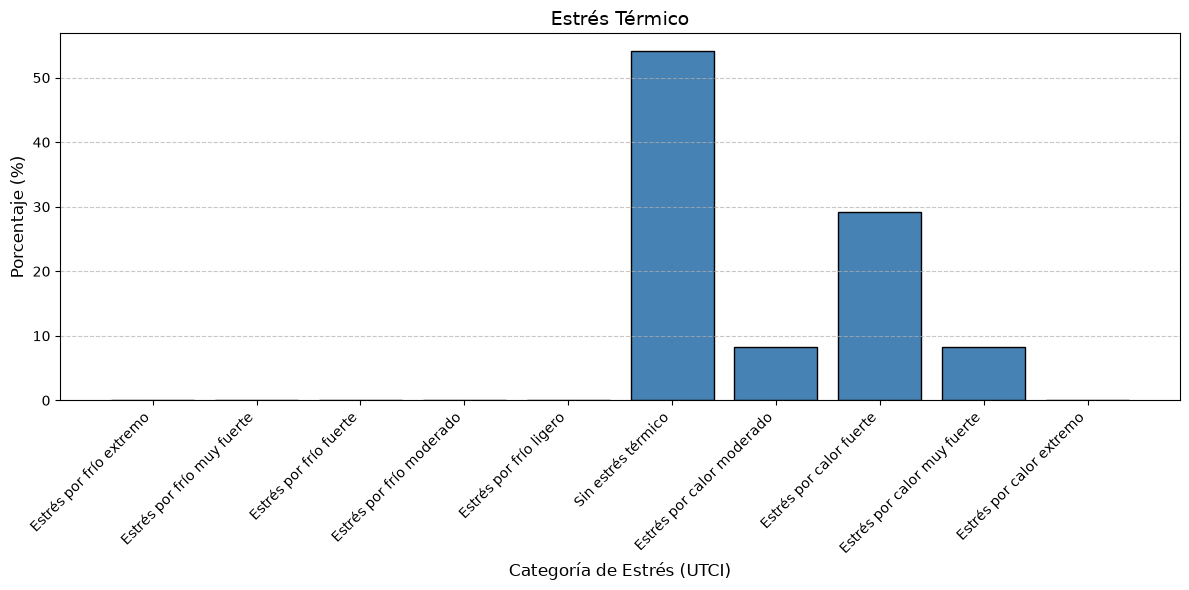

In [ ]:


punto_prueba = stress_percentage.sel(lat=14.75, lon=-92.25, method="nearest") 	

fig, ax = plt.subplots(figsize=(12, 6))  

ax.bar(
    punto_prueba["category_label"].values,  
    punto_prueba["utci"].values,           
    color="steelblue", 
    edgecolor="black"
)

ax.set_title("Estrés Térmico", fontsize=14)
ax.set_ylabel("Porcentaje (%)", fontsize=12)
ax.set_xlabel("Categoría de Estrés (UTCI)", fontsize=12)

plt.xticks(rotation=45, ha="right", fontsize=10)

ax.grid(axis="y", linestyle="--", alpha=0.7)  

plt.tight_layout() 
plt.show()
